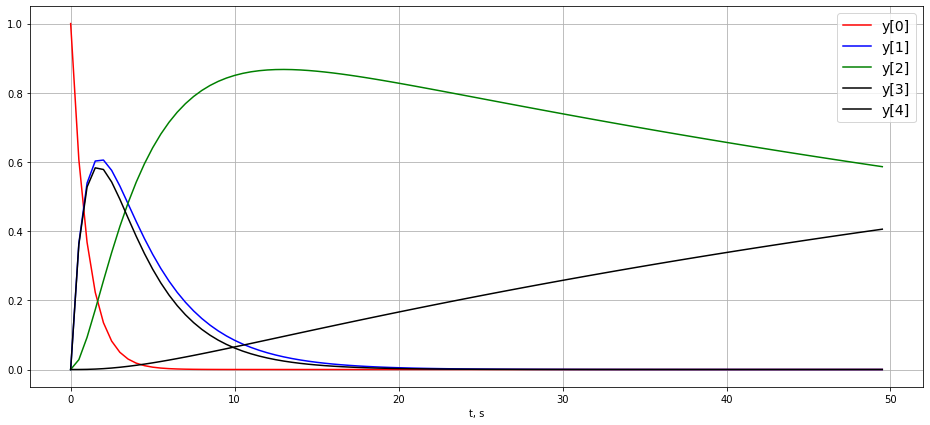

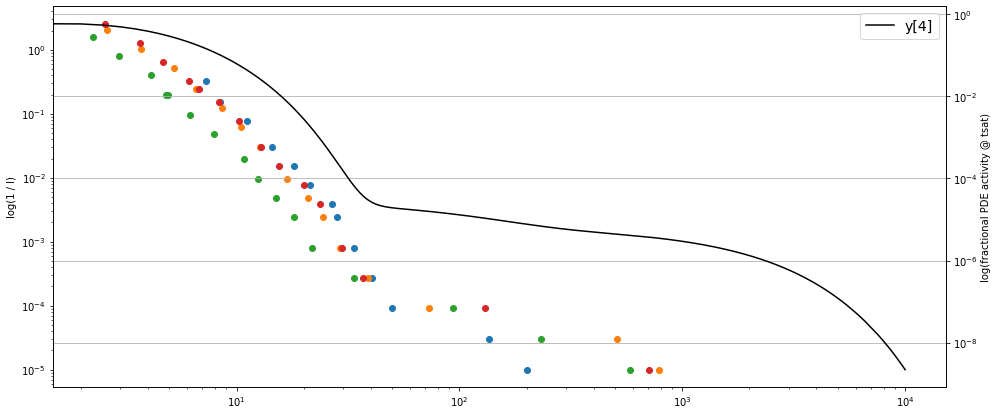

In [78]:
#v. 20241227.1
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

input_dir = './data/quenching/'
output_dir = './output/quenching/'
filenames = ['cell1 12.01.2024 red.txt',
             'cell1 13.01.2022 red.txt',
             'cell1 21.01.2024 red.txt',
             'cell1 30.12.2021red.txt'
             ]   # в файле в первой колонке - время, во второй колонке - 1/интенсивность.

aII = 1                 # Fractional activity of non-phosphorylated Meta II
aIIp = 0.012            # Phosphorylated Meta II
aM = 0.000009           # Averaged activity of all metas, P+/- Arr +/-, continious and discrete
aO = 20 * 10 ** -7      # Activity of opsin
aR = 10 ** -9           # Activity of rhodopsin
kII = 1.0               # Rate constant of MII phosphorylation
kA = 0.28               # Rate constant of arresting binding
kM = 1 / 84             # Rate of metas' decay
kR = 8 * 10 ** -4       # Rate of rhodopsin regenerator
kT = 0.33               # Rate of T* quenching

t0 = 0                  # Left border, s
tf = 9999.5             # Right border, s
n = 20000               # Number of points


intensities = [[] for i in range(len(filenames))]
intensities_t = [[] for i in range(len(filenames))]
for i, filename in enumerate(filenames):
    with open(input_dir + filename, 'r', encoding='utf-8') as file:
        for line in file:
            try:
                intensity_t, intensity = (float('0' if num == '.' else num) for num in line.split())
            except ValueError:
                continue
            intensities_t[i].append(intensity_t)
            intensities[i].append(intensity)
        intensities[i] = np.array(intensities[i])
        intensities_t[i] = np.array(intensities_t[i])


t = np.linspace(t0, tf, n)
y0 = [1,        # Active MII
      0,        # Phosphorylated MII
      0,        # All metas phosphorylated and arrested
      0,        # Naked opsin
      0]        # Trunsduction
y0 = np.array(y0)


def D(t, y):
    return [-kII * y[0],
            kII * y[0] - kA * y[1],
            kA * y[1] - kM * y[2],
            kM * y[2] - kR * y[3],
            aII * y[0] + aIIp * y[1] + aM * y[2] + aO * y[3] - kT * y[4]]


# http://studhub.jinr.ru:8080/books/Part_2.html
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html
sol = solve_ivp(fun=D, t_span=[t0, tf], y0=y0, t_eval=t, method='RK45', atol=1e-12)


fig, ax = plt.subplots()
ax.plot(t[:100], sol.y[0][:100], 'r', label='y[0]')
ax.plot(t[:100], sol.y[1][:100], 'b', label='y[1]')
ax.plot(t[:100], sol.y[2][:100], 'g', label='y[2]')
ax.plot(t[:100], sol.y[3][:100], 'black', label='y[3]')
ax.plot(t[:100], sol.y[4][:100], 'black', label='y[4]')
fig.set_figwidth(16)
fig.set_figheight(7)
ax.set_xlabel('t, s')
ax.legend(prop={"size": 14})
ax.grid()


fig, ax1 = plt.subplots()
fig.set_figwidth(16)
fig.set_figheight(7)
ax2 = ax1.twinx()
ax2.plot(t, sol.y[4], 'black', label='y[4]')

for i in range(len(filenames)):
    ax1.plot(intensities_t[i], intensities[i], 'o')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax2.set_yscale('log')

ax1.set_ylabel('log(1 / I)')
ax2.set_ylabel('log(fractional PDE activity @ tsat)')

ax2.legend(prop={"size": 14})
ax2.grid()

In [79]:
with open(f'{output_dir}quenching.txt', 'w', encoding='utf-8') as file:
    for i in range(n):
        file.write(f'{t[i]}\t{sol.y[0][i]}\t{sol.y[1][i]}\t{sol.y[2][i]}\t{sol.y[3][i]}\t{sol.y[4][i]}\n')